# Model Error Along Candidate Directions

This notebook studies the response

$$u = \sin(x+y) + \varepsilon$$

with 10% additive Gaussian noise. The true one-dimensional direction is $x+y$, corresponding to $\theta/\pi=0.25$.


## 1. Imports and project paths

Load the numerical libraries and make the local MI-DL and SI-DL implementations available. Output files are written relative to this notebook directory.


In [1]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

OUTPUT_DIR = Path.cwd()
CSV_DIR = OUTPUT_DIR / "csv"
PROJECT_ROOT = OUTPUT_DIR.parents[1]
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))

for project_path in (PROJECT_ROOT / "Compare" / "MI-DL", PROJECT_ROOT / "SI-DL-main"):
    if str(project_path) not in sys.path:
        sys.path.insert(0, str(project_path))

import midl
import SI_DL


## 2. Experiment settings

The angle grid contains 241 equally spaced directions from $0$ to $\pi$. The same train/test split is used for every direction so that differences in error come only from the candidate coordinate.


In [2]:
# Reproducibility and data settings
RANDOM_STATE = 42
N_SAMPLES = 500
NOISE_PERCENT = 10
TEST_SIZE = 0.25
N_THETA = 241

# MI-DL settings
MI_K_NEIGHBORS = 6

# SI-DL bandwidth search
SI_BANDWIDTHS = np.linspace(0.03, 0.30, 10)
SI_CV_FOLDS = 5

# GPR settings
GPR_LENGTH_SCALE = 1.0
GPR_ALPHA = 1e-12

# Short output names
SAMPLES_CSV = CSV_DIR / "samples.csv"
ERRORS_CSV = CSV_DIR / "errors.csv"
ERROR_PLOT = OUTPUT_DIR / "model_error.png"

METHOD_COLORS = {
    "MI-DL": "#3268a8",
    "SI-DL": "#d26b4f",
    "GPR": "#3a9d5c",
}


## 3. Generate the noisy samples

Draw $x$ and $y$ uniformly on $[0,5]$. The noise standard deviation is 10% of the standard deviation of the clean response. Only the final sample table is saved; no intermediate arrays are written to disk.


In [3]:
CSV_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(RANDOM_STATE)
x = rng.uniform(0.0, 5.0, size=N_SAMPLES)
y = rng.uniform(0.0, 5.0, size=N_SAMPLES)
u_clean = np.sin(x + y)
noise_scale = (NOISE_PERCENT / 100.0) * np.std(u_clean, ddof=0)
noise = rng.normal(0.0, noise_scale, size=N_SAMPLES)
u_noisy = u_clean + noise

samples = pd.DataFrame({
    "x": x,
    "y": y,
    "u_clean": u_clean,
    "noise": noise,
    "u_noisy": u_noisy,
})
samples.to_csv(SAMPLES_CSV, index=False)
samples.head()


,x,y,u_clean,noise,u_noisy
0,3.869780,3.683528,0.955137,-0.053908,0.901229
1,2.194392,4.432014,0.336522,0.067139,0.403662
2,4.292990,4.605286,0.502512,0.002514,0.505026
3,3.486840,2.518165,-0.274607,-0.020540,-0.295147
4,0.470887,2.601376,0.069275,-0.007712,0.061562


## 4. Create one fixed train/test split

MI-DL and SI-DL are evaluated on the training data. GPR is fitted on the same training data and evaluated on the held-out test data. All errors are normalized by the training-response variance.


In [4]:
all_indices = np.arange(N_SAMPLES)
train_idx, test_idx = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

u_train = u_noisy[train_idx]
u_test = u_noisy[test_idx]
error_scale = float(np.var(u_train, ddof=0))
theta_values = np.linspace(0.0, np.pi, N_THETA)
theta_over_pi = theta_values / np.pi

print(f"Training samples: {train_idx.size}")
print(f"Test samples: {test_idx.size}")
print(f"Normalization variance: {error_scale:.6f}")


Training samples: 375
Test samples: 125
Normalization variance: 0.521879


## 5. MI-DL error curve

For each candidate angle, form

$$v_\theta=\cos(\theta)x+\sin(\theta)y$$

and evaluate the mutual-information lower-bound error on the training set.


In [5]:
mi_errors = []
mutual_information = []

for theta in theta_values:
    coordinate = np.cos(theta) * x + np.sin(theta) * y
    bound = midl.information_lower_bound(
        coordinate[train_idx],
        u_train,
        k_neighbors=MI_K_NEIGHBORS,
        random_state=RANDOM_STATE,
    )
    mi_errors.append(float(bound["epsilon_lb"] / error_scale))
    mutual_information.append(float(bound["mutual_information"]))

mi_errors = np.asarray(mi_errors)


## 6. SI-DL error curve

For each candidate direction, choose the kernel bandwidth by five-fold cross-validation and compute the unexplained-variance error $1-S_{cov}$.


In [6]:
si_errors = []
si_scores = []
si_bandwidths = []

for theta in theta_values:
    coordinate = np.cos(theta) * x + np.sin(theta) * y
    score = SI_DL.cross_validated_explained_variance_score(
        coordinate[train_idx],
        u_train,
        bandwidths=SI_BANDWIDTHS,
        cv=SI_CV_FOLDS,
        random_state=RANDOM_STATE,
    )
    si_scores.append(float(score["S_cov"]))
    si_errors.append(float(1.0 - score["S_cov"]))
    si_bandwidths.append(float(score["bandwidth"]))

si_errors = np.asarray(si_errors)


## 7. GPR test error curve

Fit a standardized one-dimensional Gaussian process at every candidate direction. The reported curve is the held-out mean-squared error divided by the same training variance.


In [7]:
gpr_errors = []
gpr_raw_mse = []

for theta in theta_values:
    coordinate = np.cos(theta) * x + np.sin(theta) * y
    v_train = coordinate[train_idx].reshape(-1, 1)
    v_test = coordinate[test_idx].reshape(-1, 1)

    kernel = ConstantKernel(1.0, constant_value_bounds="fixed") * RBF(
        GPR_LENGTH_SCALE,
        length_scale_bounds="fixed",
    )
    model = make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(
            kernel=kernel,
            alpha=GPR_ALPHA,
            normalize_y=False,
            optimizer=None,
            random_state=RANDOM_STATE,
        ),
    )
    model.fit(v_train, u_train)

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            category=RuntimeWarning,
            module=r"sklearn\.gaussian_process",
        )
        prediction = model.predict(v_test)

    mse = float(mean_squared_error(u_test, prediction))
    gpr_raw_mse.append(mse)
    gpr_errors.append(mse / error_scale)

gpr_errors = np.asarray(gpr_errors)


## 8. Collect and save the results

Combine the three error curves in one compact table. Both CSV files are stored in the `csv` subfolder.


In [8]:
errors = pd.DataFrame({
    "theta": theta_values,
    "theta_over_pi": theta_over_pi,
    "mutual_information": mutual_information,
    "mi_error": mi_errors,
    "si_score": si_scores,
    "si_error": si_errors,
    "si_bandwidth": si_bandwidths,
    "gpr_error": gpr_errors,
    "gpr_raw_mse": gpr_raw_mse,
})
errors.to_csv(ERRORS_CSV, index=False)
errors.head()


,theta,theta_over_pi,mutual_information,mi_error,si_score,si_error,si_bandwidth,gpr_error,gpr_raw_mse
0,0.00000,0.000000,0.050955,0.404155,0.010843,0.989157,0.3,1.125010,0.587119
1,0.01309,0.004167,0.055697,0.400340,0.014681,0.985319,0.3,1.122371,0.585741
2,0.02618,0.008333,0.053493,0.402109,0.019429,0.980571,0.3,1.107852,0.578165
3,0.03927,0.012500,0.062095,0.395250,0.025064,0.974936,0.3,1.088916,0.568282
4,0.05236,0.016667,0.072403,0.387185,0.031546,0.968454,0.3,1.064407,0.555492


## 9. Plot the normalized model error

Only the normalized squared-error figure is retained. The former L2-error figure is intentionally omitted.


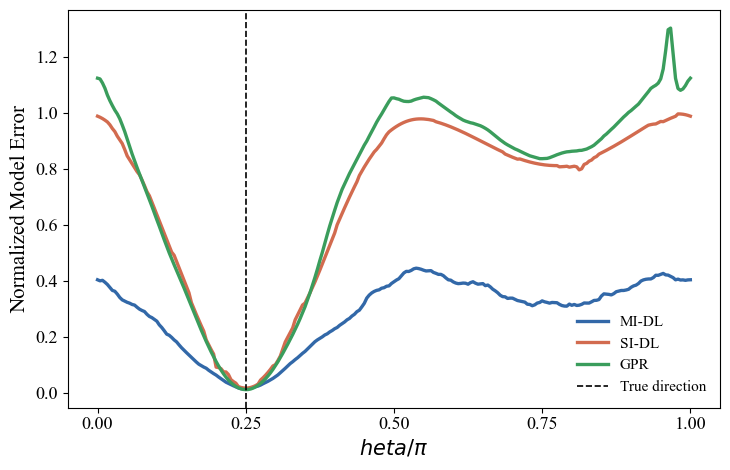

In [9]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(theta_over_pi, mi_errors, linewidth=2.4, color=METHOD_COLORS["MI-DL"], label="MI-DL")
ax.plot(theta_over_pi, si_errors, linewidth=2.4, color=METHOD_COLORS["SI-DL"], label="SI-DL")
ax.plot(theta_over_pi, gpr_errors, linewidth=2.4, color=METHOD_COLORS["GPR"], label="GPR")
ax.axvline(0.25, color="black", linestyle="--", linewidth=1.2, label="True direction")
ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax.set_xlabel(r"$	heta/\pi$", fontsize=15)
ax.set_ylabel("Normalized Model Error", fontsize=15)
ax.tick_params(axis="both", labelsize=13)
ax.legend(frameon=False, fontsize=11)
fig.tight_layout()
fig.savefig(ERROR_PLOT, dpi=240)
plt.show()


## 10. Best directions

The table below reports the minimum-error direction for each method. Values close to 0.25 recover the analytical direction $x+y$.


In [10]:
best_results = pd.DataFrame([
    {
        "method": "MI-DL",
        "best_theta_over_pi": errors.loc[errors["mi_error"].idxmin(), "theta_over_pi"],
        "minimum_error": errors["mi_error"].min(),
    },
    {
        "method": "SI-DL",
        "best_theta_over_pi": errors.loc[errors["si_error"].idxmin(), "theta_over_pi"],
        "minimum_error": errors["si_error"].min(),
    },
    {
        "method": "GPR",
        "best_theta_over_pi": errors.loc[errors["gpr_error"].idxmin(), "theta_over_pi"],
        "minimum_error": errors["gpr_error"].min(),
    },
])

print(f"Saved: {SAMPLES_CSV.relative_to(OUTPUT_DIR)}")
print(f"Saved: {ERRORS_CSV.relative_to(OUTPUT_DIR)}")
print(f"Saved: {ERROR_PLOT.name}")
best_results


Saved: csv/samples.csv
Saved: csv/errors.csv
Saved: model_error.png


,method,best_theta_over_pi,minimum_error
0,MI-DL,0.25,0.013214
1,SI-DL,0.25,0.016777
2,GPR,0.25,0.011258
